# Getting started with `splinenorm`

This is the first hands-on example of the `splinenorm` package. It introduces the two core steps of spline-based continuum modeling:

1. **`SplineModel`** — build a B-spline design matrix from a reference spectrum.
2. **`solve_linear`** — fit non-negative component amplitudes with inverse-variance weighting.

To keep the setup simple and the result easy to validate, we use a **synthetic test case**: a PHOENIX stellar template resampled to the SPIROU wavelength grid (order 46), multiplied by a toy **parabolic blaze function**. Because we know the injected blaze exactly, we can verify that the fitted continuum recovers it.

**What you will learn**
- How to construct spline basis components that modulate a template spectrum.
- How to fit a smooth continuum envelope to observed (here, blazed) flux.
- How to assess injection–recovery of the blaze and the continuum-normalized spectrum.

**Workflow**
1. Load the resampled PHOENIX spectrum and inject a parabolic blaze.
2. Build spline basis components from the intrinsic template with `SplineModel`.
3. Solve for amplitudes with `solve_linear`.
4. Compare the recovered blaze and normalized spectrum to the known truth.

For an application to **real spectroscopic data** (M-dwarf echelle spectrum with measured uncertainties), see [`fit_continuum.ipynb`](fit_continuum.ipynb).

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from splinenorm.functions import solve_linear
from splinenorm.spline_model import SplineModel

%matplotlib inline
plt.style.use("default")

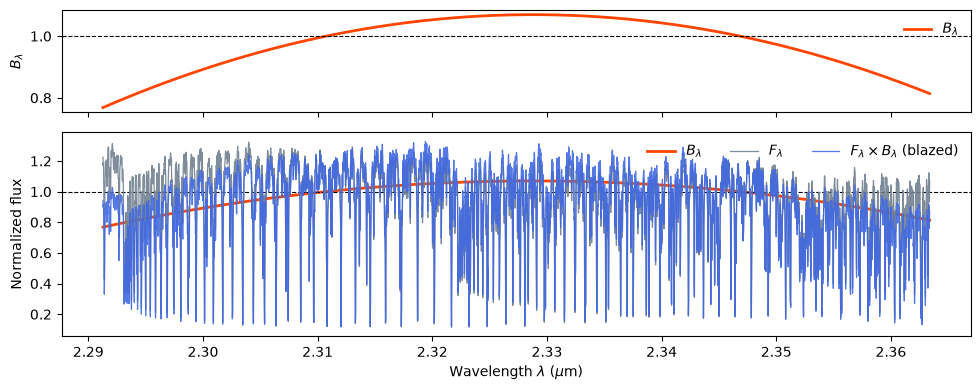

In [8]:
data_dir = Path("../data")
file_phoenix_resampled = data_dir / "lte02500-5.00-0.0.PHOENIX-NewEra-ACES-COND-2023.HSR_SPIROU.txt"

phoenix_data = np.loadtxt(file_phoenix_resampled, comments="#")
wavelength = phoenix_data[:, 0]
flux_intrinsic = phoenix_data[:, 1] / np.median(phoenix_data[:, 1])

# Inject a toy parabolic blaze function (second-order polynomial in wavelength)
blaze_coefficients = np.array([-200.0, 0.0, 1.0])
x = wavelength - np.mean(wavelength)
blaze_function = np.poly1d(blaze_coefficients)(x)
blaze_function /= np.median(blaze_function)

flux = flux_intrinsic * blaze_function
err = 0.01 * flux  # uniform 1% uncertainty for this synthetic demo

fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True, gridspec_kw={"height_ratios": [1, 2]})
for axi in axes:
    axi.plot(wavelength, blaze_function, label=r"$B_\lambda$", color="orangered", lw=2)
    axi.axhline(1.0, color="k", ls="--", lw=0.8)

axes[0].set_ylabel(r"$B_\lambda$")
axes[0].legend(loc="upper right", frameon=False)

axes[1].plot(wavelength, flux_intrinsic, label=r"$F_\lambda$", color="slategray", lw=0.9, alpha=0.9)
axes[1].plot(wavelength, flux, label=r"$F_\lambda \times B_\lambda$ (blazed)", color="royalblue", lw=0.9, alpha=0.9)
axes[1].set_xlabel(r"Wavelength $\lambda$ ($\mu$m)")
axes[1].set_ylabel("Normalized flux")
axes[1].legend(ncol=3,loc="upper right", frameon=False)

fig.tight_layout()
plt.show()


## 1. Build the spline basis

`SplineModel` decomposes a reference spectrum into `n_knots` spline components. Here the reference is the intrinsic PHOENIX template (`flux_intrinsic`), so each component represents a localized modulation of the model spectrum. Their linear combination can reproduce the blazed continuum envelope.

In [9]:
n_knots = 15
reference_spectrum = flux_intrinsic

spline_model = SplineModel(n_knots=n_knots)
spline_components = spline_model(reference_spectrum)

print(f"Spline components shape: {spline_components.shape}")

Spline components shape: (15, 4088)


## 2. Linear fit

We solve for non-negative amplitudes that best reproduce the **blazed** flux. The fitted continuum should recover the injected blaze envelope when divided by the intrinsic template.

In [10]:
inverse_variance = err**-2

amplitudes = solve_linear(flux, inverse_variance, spline_components)
continuum_model = amplitudes @ spline_components
recovered_blaze = continuum_model / flux_intrinsic
normalized_flux = flux / continuum_model

print(f"Amplitudes: {amplitudes}")
print(f"Blaze RMS recovery error: {np.sqrt(np.mean((recovered_blaze - blaze_function)**2)):.2e}")
print(f"Normalization RMS deviation from unity: {np.sqrt(np.mean((normalized_flux - 1.0)**2)):.2e}")

Amplitudes: [0.76815591 0.85330022 0.92333558 0.97892116 1.02070314 1.04931525
 1.06537984 1.06950794 1.06230019 1.04434674 1.01622731 0.97851155
 0.93175771 0.87651417 0.813317  ]
Blaze RMS recovery error: 8.64e-07
Normalization RMS deviation from unity: 9.63e-07


## 3. Injection–recovery diagnostics

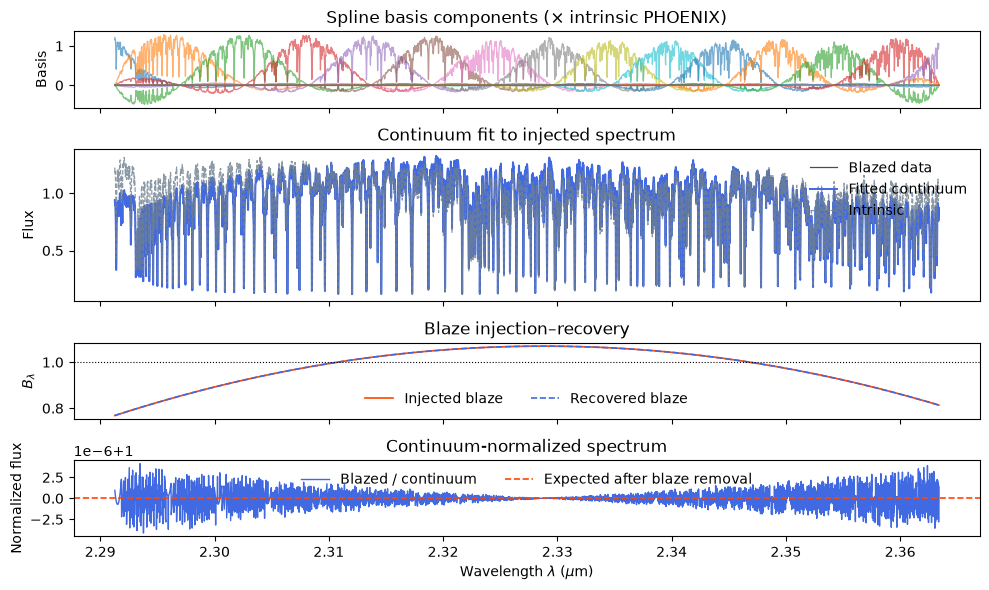

In [11]:
line_width = 0.9
fig, axes = plt.subplots(4, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [1,2,1,1]})

# Spline basis components
for component in spline_components:
    axes[0].plot(wavelength, component, alpha=0.6, lw=line_width)
axes[0].set_ylabel("Basis")
axes[0].set_title("Spline basis components (× intrinsic PHOENIX)")

# Blazed data and fitted continuum
axes[1].plot(wavelength, flux, color="black", alpha=0.7, lw=line_width, label="Blazed data")
axes[1].plot(wavelength, continuum_model, color="royalblue", lw=1.4, label="Fitted continuum")
axes[1].plot(wavelength, flux_intrinsic, color="slategray", lw=0.9, ls="--", alpha=0.8, label="Intrinsic")
axes[1].set_ylabel("Flux")
axes[1].legend(loc="upper right", frameon=False)
axes[1].set_title("Continuum fit to injected spectrum")

# Blaze injection vs recovery
axes[2].plot(wavelength, blaze_function, color="orangered", lw=1.2, label="Injected blaze")
axes[2].plot(wavelength, recovered_blaze, color="royalblue", lw=1.2, ls="--", label="Recovered blaze")
axes[2].axhline(1.0, color="k", ls=":", lw=0.8)
axes[2].set_ylabel(r"$B_\lambda$")
axes[2].legend(ncol=2, loc="lower center", frameon=False)
axes[2].set_title("Blaze injection–recovery")

# Continuum-normalized spectrum (blaze removed)
axes[3].plot(wavelength, normalized_flux, color="royalblue", lw=1.0, label="Blazed / continuum")
axes[3].axhline(1.0, color="orangered", lw=1.2, ls="--", label="Expected after blaze removal")
axes[3].set_ylabel("Normalized flux")
axes[3].legend(ncol=2,loc="upper center", frameon=False)
axes[3].set_title("Continuum-normalized spectrum")

axes[-1].set_xlabel(r"Wavelength $\lambda$ ($\mu$m)")

fig.tight_layout()
fig.savefig("remove_continuum_diagnostics.png", dpi=200, bbox_inches="tight")
plt.show()

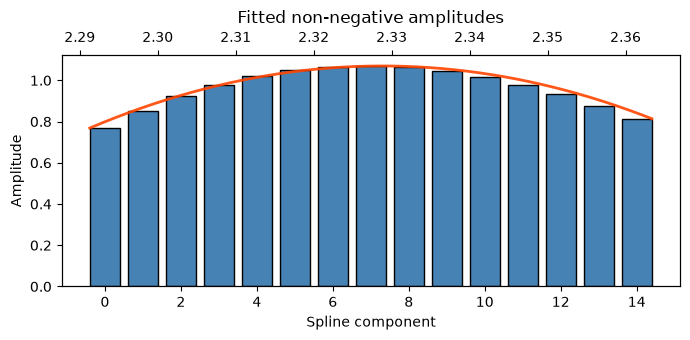

In [12]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(np.arange(n_knots), amplitudes, color="steelblue", edgecolor="black")

ax_wavelength = ax.twiny()
ax_wavelength.plot(wavelength, blaze_function, color="orangered", lw=2, label="Injected blaze", alpha=0.9)
ax.set_xlabel("Spline component")
ax.set_ylabel("Amplitude")
ax.set_title("Fitted non-negative amplitudes")
fig.tight_layout()
plt.show()

## Next steps

This notebook used synthetic data with a known blaze so that the fit could be checked against ground truth. To apply the same workflow to a **real observed spectrum** — including proper error weighting and continuum normalization of M-dwarf data — continue with [`fit_continuum.ipynb`](fit_continuum.ipynb).